# EEG-Based Alzheimer's Disease Classification

### All-Subject Feature Extraction — MNE-Python & Machine Learning

This notebook applies the EEG preprocessing and spectral feature-extraction workflow developed in the pilot analysis to the complete OpenNeuro `ds004504` dataset.

**Subjects:** 88  
**Dataset:** OpenNeuro `ds004504`

The goal is to generate a reproducible subject-level EEG feature dataset for subsequent machine-learning analysis.

In [1]:
from pathlib import Path
import mne
import pandas as pd
import numpy as np

In [2]:
data_path = Path("../data")

participants = pd.read_csv(
    data_path / "participants.tsv",
    sep="\t"
)

participants.head()

,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22


In [3]:
subject_ids = participants["participant_id"].tolist()

print("Number of subjects:", len(subject_ids))
print("First 5 subjects:", subject_ids[:5])

Number of subjects: 88
First 5 subjects: ['sub-001', 'sub-002', 'sub-003', 'sub-004', 'sub-005']


In [4]:
eeg_files = {
    subject_id: data_path / subject_id / "eeg" / f"{subject_id}_task-eyesclosed_eeg.set"
    for subject_id in subject_ids
}

missing_files = [
    subject_id
    for subject_id, file_path in eeg_files.items()
    if not file_path.exists()
]

print("Total EEG files found:", len(subject_ids) - len(missing_files))
print("Missing EEG files:", len(missing_files))

if missing_files:
    print("Missing subjects:", missing_files)

Total EEG files found: 88
Missing EEG files: 0


In [5]:
raw = mne.io.read_raw_eeglab(
    eeg_files[subject_ids[0]],
    preload=False
)

print(raw)

Reading C:\Users\Saunak Das\alzheimers-eeg-ml\notebooks\..\data\sub-001\eeg\sub-001_task-eyesclosed_eeg.set
<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~26 KiB, data not loaded>


In [6]:
raw.load_data()

Reading 0 ... 299899  =      0.000 ...   599.798 secs...


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [7]:
raw_processed = raw.copy()

raw_processed.notch_filter(freqs=50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)



<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [8]:
raw_for_ica = raw_processed.copy()

raw_for_ica.set_eeg_reference("average")

raw_for_ica.filter(
    l_freq=1.0,
    h_freq=100.0
)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 1651 samples (3.302 s)



<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [9]:
from mne.preprocessing import ICA

ica = ICA(
    n_components=18,
    method="infomax",
    fit_params=dict(extended=True),
    rng=97,
    max_iter="auto"
)

In [10]:
ica.fit(raw_for_ica)

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by number: 18 components
Computing Extended Infomax ICA
Fitting ICA took 183.5s.


Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (299900 samples)
ICA components,18
Available PCA components,19
Channel types,eeg
ICA components marked for exclusion,—


In [11]:
from mne_icalabel import label_components

In [12]:
labels = label_components(
    raw_for_ica,
    ica,
    method="iclabel"
)

In [13]:
print(labels["labels"])

['eye blink', 'eye blink', 'brain', 'eye blink', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain', 'muscle artifact', 'brain', 'brain', 'brain', 'brain', 'brain', 'brain']


In [14]:
for i in range(len(labels["labels"])):
    print(i, labels["labels"][i], labels["y_pred_proba"][i])

0 eye blink 0.9963979
1 eye blink 0.9988411
2 brain 0.9852952
3 eye blink 0.9515386
4 brain 0.38274366
5 brain 0.81359595
6 brain 0.9630745
7 brain 0.8186052
8 brain 0.9286226
9 brain 0.9962074
10 brain 0.59794605
11 muscle artifact 0.29718754
12 brain 0.6283953
13 brain 0.9945932
14 brain 0.9920022
15 brain 0.702454
16 brain 0.8941432
17 brain 0.6559181


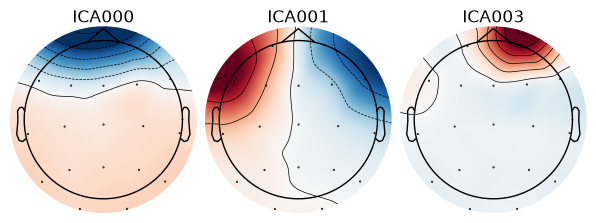

In [16]:
ica.plot_components(picks=[0, 1, 3]);

Creating RawArray with float64 data, n_channels=3, n_times=299900
    Range : 0 ... 299899 =      0.000 ...   599.798 secs
Ready.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


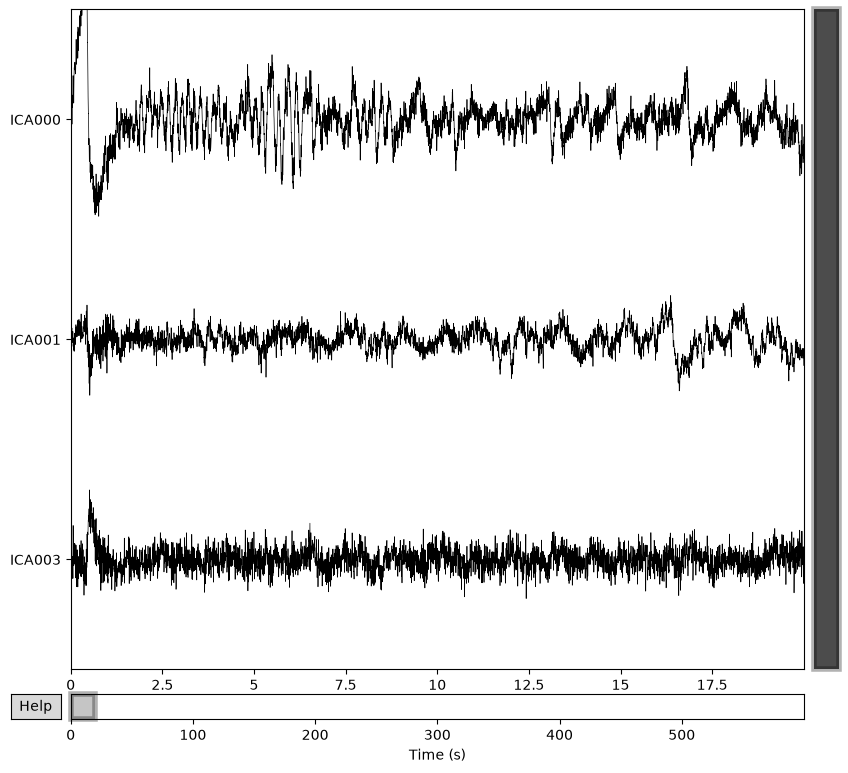

In [18]:
ica.plot_sources(raw_for_ica, picks=[0, 1, 3]);

In [19]:
ica.exclude = [0, 1, 3]

In [21]:
raw_clean = raw_processed.copy()

raw_clean.set_eeg_reference("average")

ica.apply(raw_clean)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Applying ICA to Raw instance
    Transforming to ICA space (18 components)
    Zeroing out 3 ICA components
    Projecting back using 19 PCA components


<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

In [22]:
epochs = mne.make_fixed_length_epochs(
    raw_clean,
    duration=4.0,
    preload=True
)

Not setting metadata
149 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 149 events and 2000 original time points ...
0 bad epochs dropped


In [23]:
epochs_psd = epochs.compute_psd(
    method="welch",
    fmin=1,
    fmax=45
)

Effective window size : 4.000 (s)


In [24]:
# Delta: 1–4 Hz
delta_mask = (
    (epochs_psd.freqs >= 1) &
    (epochs_psd.freqs < 4)
)

delta_power = np.trapezoid(
    epochs_psd.get_data()[:, :, delta_mask],
    x=epochs_psd.freqs[delta_mask],
    axis=-1
)


# Theta: 4–8 Hz
theta_mask = (
    (epochs_psd.freqs >= 4) &
    (epochs_psd.freqs < 8)
)

theta_power = np.trapezoid(
    epochs_psd.get_data()[:, :, theta_mask],
    x=epochs_psd.freqs[theta_mask],
    axis=-1
)


# Alpha: 8–13 Hz
alpha_mask = (
    (epochs_psd.freqs >= 8) &
    (epochs_psd.freqs < 13)
)

alpha_power = np.trapezoid(
    epochs_psd.get_data()[:, :, alpha_mask],
    x=epochs_psd.freqs[alpha_mask],
    axis=-1
)


# Beta: 13–30 Hz
beta_mask = (
    (epochs_psd.freqs >= 13) &
    (epochs_psd.freqs < 30)
)

beta_power = np.trapezoid(
    epochs_psd.get_data()[:, :, beta_mask],
    x=epochs_psd.freqs[beta_mask],
    axis=-1
)


# Gamma: 30–45 Hz
gamma_mask = (
    (epochs_psd.freqs >= 30) &
    (epochs_psd.freqs <= 45)
)

gamma_power = np.trapezoid(
    epochs_psd.get_data()[:, :, gamma_mask],
    x=epochs_psd.freqs[gamma_mask],
    axis=-1
)

print(delta_power.shape)
print(theta_power.shape)
print(alpha_power.shape)
print(beta_power.shape)
print(gamma_power.shape)

(149, 19)
(149, 19)
(149, 19)
(149, 19)
(149, 19)


In [25]:
total_power = (
    delta_power
    + theta_power
    + alpha_power
    + beta_power
    + gamma_power
)

In [26]:
delta_relative = delta_power / total_power
theta_relative = theta_power / total_power
alpha_relative = alpha_power / total_power
beta_relative = beta_power / total_power
gamma_relative = gamma_power / total_power

In [27]:
delta_epoch = delta_relative.mean(axis=1)
theta_epoch = theta_relative.mean(axis=1)
alpha_epoch = alpha_relative.mean(axis=1)
beta_epoch = beta_relative.mean(axis=1)
gamma_epoch = gamma_relative.mean(axis=1)

In [28]:
delta_subject = delta_epoch.mean()
theta_subject = theta_epoch.mean()
alpha_subject = alpha_epoch.mean()
beta_subject = beta_epoch.mean()
gamma_subject = gamma_epoch.mean()

In [29]:
subject_features = pd.DataFrame({
    "delta": [delta_subject],
    "theta": [theta_subject],
    "alpha": [alpha_subject],
    "beta": [beta_subject],
    "gamma": [gamma_subject]
})

subject_features

,delta,theta,alpha,beta,gamma
0,0.345179,0.328017,0.102048,0.129601,0.095154


In [30]:
subject_info = participants[
    participants["participant_id"] == subject_ids[0]
].iloc[0]

subject_info

participant_id    sub-001
Gender                  F
Age                    57
Group                   A
MMSE                   16
Name: 0, dtype: object

In [31]:
subject_features["subject"] = subject_info["participant_id"]
subject_features["group"] = subject_info["Group"]
subject_features["age"] = subject_info["Age"]
subject_features["MMSE"] = subject_info["MMSE"]

subject_features

,delta,theta,alpha,beta,gamma,subject,group,age,MMSE
0,0.345179,0.328017,0.102048,0.129601,0.095154,sub-001,A,57,16


In [33]:
ica.exclude = []

for i in range(len(labels["labels"])):
    if labels["labels"][i] == "eye blink":
        if labels["y_pred_proba"][i] >= 0.8:
            ica.exclude.append(i)

print(ica.exclude)

[0, 1, 3]


In [37]:
all_subject_features = []

for subject_id in subject_ids:

    print("Processing:", subject_id)

    # Load EEG
    raw = mne.io.read_raw_eeglab(
        eeg_files[subject_id],
        preload=True
    )

    # 50 Hz notch filter
    raw.notch_filter(freqs=50)

    # Prepare data for ICA
    raw_for_ica = raw.copy()
    raw_for_ica.set_eeg_reference("average")
    raw_for_ica.filter(
        l_freq=1.0,
        h_freq=100.0
    )

    # Create and fit ICA
    ica = ICA(
        n_components=18,
        method="infomax",
        fit_params=dict(extended=True),
        rng=97,
        max_iter="auto"
    )

    ica.fit(raw_for_ica)

    # Classify ICA components
    labels = label_components(
        raw_for_ica,
        ica,
        method="iclabel"
    )

    # Automatically select strong eye-blink components
    ica.exclude = []

    for i in range(len(labels["labels"])):
        if labels["labels"][i] == "eye blink":
            if labels["y_pred_proba"][i] >= 0.8:
                ica.exclude.append(i)

    # Create cleaned EEG
    raw_clean = raw.copy()
    raw_clean.set_eeg_reference("average")
    ica.apply(raw_clean)

    # Create 4-second epochs
    epochs = mne.make_fixed_length_epochs(
        raw_clean,
        duration=4.0,
        preload=True
    )

    # Calculate PSD
    epochs_psd = epochs.compute_psd(
        method="welch",
        fmin=1,
        fmax=45
    )

    # Get PSD data
    psd_data = epochs_psd.get_data()

    # Delta
    delta_mask = (
        (epochs_psd.freqs >= 1) &
        (epochs_psd.freqs < 4)
    )

    delta_power = np.trapezoid(
        psd_data[:, :, delta_mask],
        x=epochs_psd.freqs[delta_mask],
        axis=-1
    )

    # Theta
    theta_mask = (
        (epochs_psd.freqs >= 4) &
        (epochs_psd.freqs < 8)
    )

    theta_power = np.trapezoid(
        psd_data[:, :, theta_mask],
        x=epochs_psd.freqs[theta_mask],
        axis=-1
    )

    # Alpha
    alpha_mask = (
        (epochs_psd.freqs >= 8) &
        (epochs_psd.freqs < 13)
    )

    alpha_power = np.trapezoid(
        psd_data[:, :, alpha_mask],
        x=epochs_psd.freqs[alpha_mask],
        axis=-1
    )

    # Beta
    beta_mask = (
        (epochs_psd.freqs >= 13) &
        (epochs_psd.freqs < 30)
    )

    beta_power = np.trapezoid(
        psd_data[:, :, beta_mask],
        x=epochs_psd.freqs[beta_mask],
        axis=-1
    )

    # Gamma
    gamma_mask = (
        (epochs_psd.freqs >= 30) &
        (epochs_psd.freqs <= 45)
    )

    gamma_power = np.trapezoid(
        psd_data[:, :, gamma_mask],
        x=epochs_psd.freqs[gamma_mask],
        axis=-1
    )

    # Total power
    total_power = (
        delta_power
        + theta_power
        + alpha_power
        + beta_power
        + gamma_power
    )

    # Relative power
    delta_relative = delta_power / total_power
    theta_relative = theta_power / total_power
    alpha_relative = alpha_power / total_power
    beta_relative = beta_power / total_power
    gamma_relative = gamma_power / total_power

    # Average across channels
    delta_epoch = delta_relative.mean(axis=1)
    theta_epoch = theta_relative.mean(axis=1)
    alpha_epoch = alpha_relative.mean(axis=1)
    beta_epoch = beta_relative.mean(axis=1)
    gamma_epoch = gamma_relative.mean(axis=1)

    # Average across epochs
    delta_subject = delta_epoch.mean()
    theta_subject = theta_epoch.mean()
    alpha_subject = alpha_epoch.mean()
    beta_subject = beta_epoch.mean()
    gamma_subject = gamma_epoch.mean()

    # Get subject information
    subject_info = participants[
        participants["participant_id"] == subject_id
    ].iloc[0]

    # Create subject feature row
    subject_features = pd.DataFrame({
        "subject": [subject_id],
        "group": [subject_info["Group"]],
        "age": [subject_info["Age"]],
        "MMSE": [subject_info["MMSE"]],
        "delta": [delta_subject],
        "theta": [theta_subject],
        "alpha": [alpha_subject],
        "beta": [beta_subject],
        "gamma": [gamma_subject]
    })

    # Add row to final collection
    all_subject_features.append(subject_features)

    print("Finished:", subject_id)

Processing: sub-001
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband

In [38]:
len(all_subject_features)

88

In [39]:
all_subject_features_df = pd.concat(
    all_subject_features,
    ignore_index=True
)

In [40]:
all_subject_features_df.shape

(88, 9)

In [41]:
all_subject_features_df.head()

,subject,group,age,MMSE,delta,theta,alpha,beta,gamma
0,sub-001,A,57,16,0.345179,0.328017,0.102048,0.129601,0.095154
1,sub-002,A,78,22,0.143655,0.154829,0.464910,0.190827,0.045779
2,sub-003,A,70,14,0.222562,0.231461,0.476515,0.053760,0.015702
3,sub-004,A,67,20,0.420912,0.277658,0.071022,0.123877,0.106531
4,sub-005,A,70,22,0.349276,0.211557,0.170443,0.193253,0.075471


In [42]:
all_subject_features_df.isna().sum()

subject    0
group      0
age        0
MMSE       0
delta      0
theta      0
alpha      0
beta       0
gamma      0
dtype: int64

In [43]:
all_subject_features_df["subject"].duplicated().sum()

np.int64(0)

In [44]:
all_subject_features_df["group"].value_counts()

group
A    36
C    29
F    23
Name: count, dtype: int64

In [45]:
all_subject_features_df.to_csv(
    "../data/all_subjects_features.csv",
    index=False
)

In [46]:
csv_path = data_path / "all_subjects_features.csv"

print(csv_path.exists())

True


# All-Subject Feature Extraction — Detailed Summary and Experimental Record

## 1. Purpose of the Analysis

This notebook extends the workflow developed and examined in the pilot analysis (`01_pilot_analysis.ipynb`) to all 88 subjects in the OpenNeuro `ds004504` dataset.

The purpose of this stage was to systematically process every subject using the same computational workflow and generate a consistent subject-level spectral feature dataset for subsequent machine-learning analysis.

Unlike the pilot notebook, which was used for detailed inspection and methodological development on `sub-001`, this notebook focuses on **reproducible automation across the complete dataset**.

---

## 2. Dataset

The dataset contains **88 subjects**:

- **36** Alzheimer's disease (AD)
- **29** Cognitively normal (CN)
- **23** Frontotemporal dementia (FTD)

The recordings contain:

- **19 scalp EEG channels**
- **Sampling frequency:** 500 Hz
- **Recording condition:** resting-state, eyes closed
- **EEG placement:** 10–20 system

The EEG recordings were stored locally and processed directly from the EEGLAB `.set` files.

The dataset itself is excluded from Git tracking.

---

## 3. Input Verification

Before automated processing, the participant metadata were loaded from:

`participants.tsv`

The subject identifiers were extracted and checked against the expected EEG file structure.

All 88 expected EEG recordings were successfully located.

### Input verification result

- **Expected subjects:** 88
- **EEG files found:** 88
- **Missing EEG files:** 0

This confirmed that the automated pipeline could access the complete set of EEG recordings.

---

## 4. Automated Processing Workflow

Each subject was processed independently using the following workflow:

**EEG loading → 50-Hz notch filtering → ICA preparation → Extended Infomax ICA → ICLabel classification → automatic artifact selection → ICA cleaning → 4-second epoching → Welch PSD → frequency-band power → relative power → channel averaging → epoch averaging → subject-level features**

Each subject produced one final feature row.

---

## 5. EEG Loading and Power-Line Noise Removal

Each EEGLAB `.set` recording was loaded using MNE-Python.

A **50-Hz notch filter** was applied to reduce the power-line component identified during the pilot analysis and supported by the dataset metadata.

The original recording was kept separate from the processed copy so that the processing steps did not overwrite the initial loaded data.

---

## 6. ICA Preparation

A separate copy of the processed EEG was prepared for Independent Component Analysis (ICA).

The ICA input was:

- Re-referenced to the common average
- Filtered from **1–100 Hz**
- Processed using Extended Infomax ICA

Because the EEG contained 19 channels and was average-referenced, **18 ICA components** were used.

A fixed random seed (`rng=97`) was used to improve reproducibility.

---

## 7. ICLabel-Based Artifact Classification

MNE-ICALabel was used to classify the independent components using ICLabel.

The classification was performed independently for every subject.

For automated artifact handling, components were excluded when:

1. The ICLabel classification was **`eye blink`**
2. The predicted probability was **at least 0.80**

This replaced manual component selection with a consistent rule that could be applied across all 88 subjects.

Only components satisfying both conditions were automatically excluded.

---

## 8. ICA Cleaning

A separate copy of the original processed EEG was created for the final cleaned signal.

The EEG was re-referenced to the common average before applying the fitted ICA solution.

The automatically selected ICLabel components were then removed using the fitted ICA decomposition.

The resulting signal was treated as the **cleaned EEG** used for subsequent epoching and spectral analysis.

---

## 9. Epoching

The cleaned continuous EEG was divided into fixed-length, non-overlapping epochs of:

**4 seconds**

At a sampling frequency of 500 Hz:

`4 s × 500 samples/s = 2,000 samples per epoch`

The number of epochs depended on the duration of each subject's recording.

Epochs were used as analysis windows for spectral feature extraction.

Importantly, epochs were **not treated as independent subjects**. They were averaged to produce one subject-level representation before the machine-learning stage.

---

## 10. Power Spectral Density Analysis

Welch's method was used to calculate the power spectral density (PSD) for every epoch and electrode.

The PSD was calculated over:

**1–45 Hz**

This frequency range was selected to cover the five predefined frequency bands used for feature extraction.

The general PSD structure was:

`epochs × 19 electrodes × frequency bins`

---

## 11. Frequency-Band Power Extraction

Five frequency bands were defined:

| Band | Frequency range |
|---|---:|
| Delta | 1–4 Hz |
| Theta | 4–8 Hz |
| Alpha | 8–13 Hz |
| Beta | 13–30 Hz |
| Gamma | 30–45 Hz |

For every epoch and electrode, the PSD was numerically integrated across each frequency band using trapezoidal integration.

This produced one band-power value for every:

**epoch × electrode**

combination.

---

## 12. Relative Power

The total power was calculated as the sum of the five extracted band-power values:

`Delta + Theta + Alpha + Beta + Gamma`

Relative power was then calculated for each band as:

`Relative band power = band power / total power`

Because the five defined bands together cover the complete **1–45 Hz** analysis range, the resulting five relative-power values for a given epoch and electrode form a normalized representation of the spectral distribution across those bands.

---

## 13. Channel Averaging

For each frequency band, the relative-power values were initially represented across:

`epochs × 19 electrodes`

The 19 electrode values were then averaged for each epoch.

This produced:

`one value per epoch`

for each of the five frequency bands.

The operation therefore reduced the spatial electrode dimension while retaining the temporal epoch dimension.

---

## 14. Epoch Averaging

The epoch-level band features were subsequently averaged across all epochs belonging to each subject.

This produced:

**one final value per frequency band per subject**

The transformation can be summarized as:

`epochs × 19 electrodes → epochs × 1 averaged feature → 1 subject-level feature`

for each of the five frequency bands.

The final EEG feature representation therefore contained:

- Delta relative power
- Theta relative power
- Alpha relative power
- Beta relative power
- Gamma relative power

---

## 15. Subject Metadata

The EEG features were combined with subject-level metadata from `participants.tsv`.

The retained metadata were:

- Subject ID
- Diagnostic group
- Age
- MMSE

Each subject therefore produced one complete row containing both EEG features and subject information.

---

## 16. Final Dataset Structure

The resulting feature dataset contains:

**88 subjects × 9 columns**

| Column | Description |
|---|---|
| `subject` | Subject identifier |
| `group` | Diagnostic group |
| `age` | Subject age |
| `MMSE` | Mini-Mental State Examination score |
| `delta` | Mean relative delta power |
| `theta` | Mean relative theta power |
| `alpha` | Mean relative alpha power |
| `beta` | Mean relative beta power |
| `gamma` | Mean relative gamma power |

The resulting structure is:

`1 row = 1 subject`

This subject-level structure is important for the later machine-learning stage because multiple epochs from the same participant are not treated as separate independent samples.

---

## 17. Quality-Control Checks

The final subject-level feature dataset was checked for:

- Expected number of subjects
- Missing values
- Duplicate subjects
- Diagnostic-group counts

The checks produced:

- **Subjects:** 88
- **Missing feature/metadata values:** 0
- **Duplicate subjects:** 0
- **AD:** 36
- **CN:** 29
- **FTD:** 23

These checks confirmed that the automated feature table was complete and contained exactly one row for each participant.

---

## 18. Output

The final subject-level feature table was saved as:

`data/all_subjects_features.csv`

The CSV contains the features and metadata required for the next stage of the project.

The dataset remains excluded from Git tracking through `.gitignore`.

---

## 19. Important Methodological Considerations

The automation was designed so that each participant was processed independently.

ICA was fitted separately for each subject, and ICLabel classification was also performed separately for each subject. Therefore, ICA component numbers were not assumed to correspond between participants.

The artifact-removal rule was based on the **ICLabel classification and probability threshold**, rather than applying the same component numbers to every subject.

The final machine-learning dataset is subject-level, allowing the subsequent train/test and cross-validation procedures to be performed at the participant level and reducing the risk of leakage caused by splitting epochs from the same subject across different datasets.

---

## 20. Completion of the Feature-Extraction Stage

The automated pipeline successfully processed all **88 subjects** and generated one subject-level feature representation for each participant.

The workflow established in this notebook is now ready to serve as the input to the machine-learning stage.

The next notebook, `03_machine_learning.ipynb`, will use `all_subjects_features.csv` to begin the classification analysis, starting with **Alzheimer's disease (AD) versus cognitively normal (CN)** subjects.

The machine-learning stage will be developed separately so that the EEG preprocessing and feature-generation workflow remains reproducible and independent from model training and evaluation.